In [1]:
import pandas as pd

df=pd.read_pickle('data.allpoems.pkl')

def filter_poem_txt(txt):
    vparas = [para.strip() for para in txt.split('\n\n') if '\n' in para.strip()]
    return '\n\n'.join(vparas)

def num_lines_txt(txt):
    return len([v for v in txt.splitlines() if v.strip()])

df['poem_txt'] = df['poem'].apply(filter_poem_txt)
df['num_lines_txt'] = df['poem_txt'].apply(num_lines_txt)

In [2]:
df[['poem_txt','num_lines_txt']]

,poem_txt,num_lines_txt
0,"In the heart of the bustling city,\nThere lies...",30
1,"In the stillness of the night\nI lay awake, co...",28
2,among\nthe c\nr\ne\na\ns\nes\n\nof the\nfa\nl\...,21
3,"In the depths of the forest, where shadows dan...",40
4,"Alas, what fate doth bring me to this pass? \n...",15
...,...,...
67310,"Talk in your sleep of Lilith,\nAnd say that sh...",20
67312,"Two days of mossy mists,\nsoft & clinging. The...",29
67313,"O! Molly Bawn, why leave me pining,\n All l...",18
67315,"Love put his bow into my hand,\n Charg'...",18


In [3]:
df[df['prompt'].fillna('').str.contains('sonnet')][['num_lines','num_lines_txt', 'poem_txt']].query('num_lines == 14')

,num_lines,num_lines_txt,poem_txt
12,14,14,When spring's first blossoms fill the air with...
24,14,14,When winter's chill doth pierce the weary soul...
69,14,14,When spring's fair blossoms grace the verdant ...
79,14,14,"When golden sunbeams filter through the trees,..."
84,14,14,"When autumn's chill pervades the fading light,..."
...,...,...,...
2941,14,14,"Upon the hill where roses bloom so fair,\nI sa..."
2949,14,14,When autumn's chill doth pierce the morning ai...
2981,14,14,"When summer's bloom has faded from the land,\n..."
3005,14,14,"Oh, how my heart doth ache with love so true,\..."


In [4]:
import sys
sys.path.insert(0,'..')
sys.path.insert(0,'/Users/ryan/github/prosodic')
# !pip install -r /Users/ryan/github/prosodic/requirements.txt

import prosodic

shaksonnets = prosodic.Text(fn='/Users/ryan/github/prosodic/corpora/corppoetry_en/en.shakespeare.txt')


In [5]:
constraints={
    'w_peak':1,
    'w_stress':1,
    's_unstress':1,
    'unres_across':1,
    'unres_within':1,
    'pentameter':1000,
    'iambic':1000,
}

meter = prosodic.Meter(
    constraints=constraints,
    resolve_optionality=True,
    max_s=1,
    max_w=2,
)

parses = shaksonnets.parse(meter=meter)

[7.72s] Parsing lineparts [8x]: 100%|█████████▉| 3065/3071 [00:51<00:00, 80.90it/s] 

In [6]:
stats_by_line = parses.stats()
stats_by_line

parse_score  \
stanza_num line_num line_txt                                       linepart_num parse_rank parse_txt                                       parse_meter parse_stress sent_num sentpart_num                
1          1        FROM fairest creatures we desire increase,     1            1          from FAI rest CREA tures WE de SIRE in CREASE   -+-+-+-+-+  -+-+---+-+   1        1                       1   
           2        That thereby beauty's rose might never die,    2            1          that THE reby BEA uty's ROSE might NE ver DIE   -+-+-+-+-+  -+++-+-+-+   1        2                       1   
           3        But as the riper should by time decease,       3            1          but AS the RIPER should.by TIME de CEASE        -+-+--+-+   ---+--+-+    1        3                    1001   
           4        His tender heir might bear his memory:         4            1          his TEN der HEIR might BEAR his ME mo RY        -+-+-+-+-+  -+-+-+-+--   1        4                       1   
           5        But thou, contracted to thine own bright eyes, 5            1          but THOU con TRAC ted TO thine OWN bright EYES  -+-+-+-+-+  ---+---+++   1        5                       3   
...                                                                                                                                                                                                ...   
154        2151     Which from Love's fire took heat perpetual,    3063         1          WHICH from LOVE'S fire TOOK heat PER pe TU al   +-+-+-+-+-  +-++++-+--   522      2587                 1006   
           2152     Growing a bath and healthful remedy            3064         1          GRO wing.a BATH and HEALT hful RE me DY         +--+-+-+-+  +--+-+-+--   522      2588                 1002   
           2153     For men diseased; but I, my mistress' thrall,  3065         1          for MEN di SEASED but I my MIS tress' THRALL    -+-+-+-+-+  -+-+---+-+   522      2588                    1   
           2154     Came there for cure, and this by that I prove, 3068         1          came THERE for CURE and THIS by THAT i PROVE    -+-+-+-+-+  +--+---+-+   522      2591                    3   
           2155     Love's fire heats water, water cools not love. 3070         1          love's FI re HEATS wa.ter WA ter COOLS not LOVE -+-+--+-+-+ ++-++-+-+-+  522      2593                    4   

                                                                                                                                                                                           parse_num_viols  \
stanza_num line_num line_txt                                       linepart_num parse_rank parse_txt                                       parse_meter parse_stress sent_num sentpart_num                    
1          1        FROM fairest creatures we desire increase,     1            1          from FAI rest CREA tures WE de SIRE in CREASE   -+-+-+-+-+  -+-+---+-+   1        1                           1   
           2        That thereby beauty's rose might never die,    2            1          that THE reby BEA uty's ROSE might NE ver DIE   -+-+-+-+-+  -+++-+-+-+   1        2                           1   
           3        But as the riper should by time decease,       3            1          but AS the RIPER should.by TIME de CEASE        -+-+--+-+   ---+--+-+    1        3                           2   
           4        His tender heir might bear his memory:         4            1          his TEN der HEIR might BEAR his ME mo RY        -+-+-+-+-+  -+-+-+-+--   1        4                           1   
           5        But thou, contracted to thine own bright eyes, 5            1          but THOU con TRAC ted TO thine OWN bright EYES  -+-+-+-+-+  ---+---+++   1        5                           3   
...                                                                                                                   

In [7]:
# stats by syll
stats_by_syll = parses.stats(by='syll')
stats_by_syll

parse_score  \
stanza_num line_num line_txt                                       linepart_num parse_rank parse_txt                                       parse_meter parse_stress sent_num sentpart_num wordtoken_num wordtoken_txt meterpos_num meterslot_num meterslot_txt                
1          1        FROM fairest creatures we desire increase,     1            1          from FAI rest CREA tures WE de SIRE in CREASE   -+-+-+-+-+  -+-+---+-+   1        1            1             FROM          1            1             from                     1   
                                                                                                                                                                                          2              fairest      2            1             FAI                      1   
                                                                                                                                                                                                                      3            1             rest                     1   
                                                                                                                                                                                          3              creatures    4            1             CREA                     1   
                                                                                                                                                                                                                      5            1             tures                    1   
...                                                                                                                                                                                                                                                                     ...   
154        2155     Love's fire heats water, water cools not love. 3070         5          love's FI re HEATS wa TER WA ter COOLS not LOVE -+-+-++-+-+ ++-++-+-+-+  522      2593         20313          water        1            1             WA                    1004   
                                                                                                                                                                                                                      2            1             ter                   1004   
                                                                                                                                                                                          20314          cools        3            1             COOLS                 1004   
                                                                                                                                                                                          20315          not          4            1             not                   1004   
                                                                                                                                                                                          20316          love         5            1             LOVE                  1004   

                                                                                                                                                                                                                                                                parse_num_viols  \
stanza_num line_num line_txt                                       linepart_num parse_rank parse_txt                                       parse_meter parse_stress sent_num sentpart_num wordtoken_num wordtoken_txt meterpos_num meterslot_num meterslot_txt                    
1          1        FROM fairest creatures we desire increase,     1            1          from FAI rest CREA tures WE de SIRE in CREASE   -+-+-+-+-+  -+-+---+-+   1        1        

In [25]:
df2=parses.scansions.stats(incl_bounded=True).reset_index()
df2

,stanza_num,line_num,line_txt,linepart_num,parse_rank,parse_txt,parse_meter,parse_stress,sent_num,sentpart_num,...,*total,*pentameter_norm,*iambic_norm,*w_peak_norm,*w_stress_norm,*s_unstress_norm,*unres_across_norm,*unres_within_norm,*total_sylls_norm,*total_norm
0,1,1,"FROM fairest creatures we desire increase,",1,1,from FAI rest CREA tures WE de SIRE in CREASE,-+-+-+-+-+,-+-+---+-+,1,1,...,1,0.0,0.0,0.000000,0.000000,0.100000,0.000000,0.000000,0.100000,0.100000
1,1,1,"FROM fairest creatures we desire increase,",1,2,from FAI rest CREA tures WE de SI re IN crease,-+-+-+-+-+-,-+-+---+-++,1,1,...,2,0.0,0.0,0.000000,0.090909,0.090909,0.000000,0.000000,0.181818,0.181818
2,1,2,"That thereby beauty's rose might never die,",2,1,that THE reby BEA uty's ROSE might NE ver DIE,-+-+-+-+-+,-+++-+-+-+,1,2,...,1,0.0,0.0,0.000000,0.100000,0.000000,0.000000,0.000000,0.100000,0.100000
3,1,2,"That thereby beauty's rose might never die,",2,2,that THE reby BEA uty's ROSE might NE ver.die,-+-+-+-+--,-+++-+-+-+,1,2,...,3,0.0,0.0,0.000000,0.200000,0.000000,0.100000,0.000000,0.200000,0.300000
4,1,2,"That thereby beauty's rose might never die,",2,3,THAT the.reby BEA uty's ROSE might NE ver DIE,+--+-+-+-+,++++-+-+-+,1,2,...,3,0.0,0.0,0.000000,0.200000,0.000000,0.000000,0.100000,0.200000,0.300000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15661,154,2155,"Love's fire heats water, water cools not love.",3070,6,love's FI re HEATS wa TER wa.ter COOLS not LOVE,-+-+-+--+-+,++-++-+-+-+,522,2593,...,7,0.0,0.0,0.181818,0.272727,0.090909,0.000000,0.090909,0.454545,0.636364
15662,154,2155,"Love's fire heats water, water cools not love.",3070,7,love's FI re HEATS wa.ter WA ter COOLS not.love,-+-+--+-+--,++-++-+-+-+,522,2593,...,6,0.0,0.0,0.090909,0.272727,0.000000,0.090909,0.090909,0.363636,0.545455
15663,154,2155,"Love's fire heats water, water cools not love.",3070,8,love's FI re HEATS wa.ter wa.ter COOLS not LOVE,-+-+----+-+,++-++-+-+-+,522,2593,...,7,0.0,0.0,0.181818,0.272727,0.000000,0.000000,0.181818,0.454545,0.636364
15664,154,2155,"Love's fire heats water, water cools not love.",3070,10,LOVE'S fire.heats WA ter WA ter COOLS not.love,+--+-+-+--,++++-+-+-+,522,2593,...,5,0.0,0.0,0.000000,0.300000,0.000000,0.200000,0.000000,0.300000,0.500000


In [107]:
parses = []
parse_dfs = []
for stanza in prosodic.progress_bar(shaksonnets.stanzas):
    for line_i,line in enumerate(stanza.lines):
        parse = prosodic.Parse(line.txt.strip(), scansion="-+-+-+-+-+")
        if parse.wordforms.num_sylls != 10: continue
        parse_df = parse.df
        parse_df['stanza_num'] = line.stanza.num
        parse_df['line_num'] = line_i+1
        # parse_df['*total'] = parse_df[[c for c in parse_df.columns if c.startswith('*') and c not in {'*pentameter'}]].sum(axis=1)
        parses.append(parse)
        parse_dfs.append(parse_df)

parses2 = [parse for parse in parses if parse.meter_str == '-+' * 5]
len(parses), len(parses2)
parses_df = pd.concat(parse_dfs)
parses_df

parse_score  parse_num_viols parse_ambig  \
parse_rank parse_txt                                      parse_meter parse_stress wordtoken_num wordtoken_txt meterpos_num meterslot_num meterslot_txt                                             
           from FAI rest CREA tures WE de SIRE in CREASE  -+-+-+-+-+  -+-+---+-+   1             FROM          1            1             from                   1.0                1        None   
                                                                                   2              fairest      2            1             FAI                    1.0                1        None   
                                                                                                               3            1             rest                   1.0                1        None   
                                                                                   3              creatures    4            1             CREA                   1.0                1        None   
                                                                                                               5            1             tures                  1.0                1        None   
...                                                                                                                                                              ...              ...         ...   
           love's FIRE heats WA ter WA ter COOLS not LOVE -+-+-+-+-+  ++++-+-+-+   6              water        6            1             WA                     2.0                2        None   
                                                                                                               7            1             ter                    2.0                2        None   
                                                                                   7              cools        8            1             COOLS                  2.0                2        None   
                                                                                   8              not          9            1             not                    2.0                2        None   
                                                                                   9              love         10           1             LOVE                   2.0                2        None   

                                                                                                                                                         parse_is_bounded meterpos_meter_val  \
parse_rank parse_txt                                      parse_meter parse_stress wordtoken_num wordtoken_txt meterpos_num meterslot_num meterslot_txt                                        
           from FAI rest CREA tures WE de SIRE in CREASE  -+-+-+-+-+  -+-+---+-+   1             FROM          1            1             from                          0                  w   
                                                                                   2              fairest      2            1             FAI                           0                  s   
                                                                                                               3            1             rest                          0                  w   
                                                                                   3              creatures    4            1             CREA                          0                  s   
                                                                                                               5            1             tures                         0                  w   
...                                                                                                                                                                   ...                ...   
           love's FIRE heats WA ter WA ter COOLS not LO

In [104]:
# df=stats_by_line.reset_index()
# df.query('parse_meter=="-+-+-+-+-+"')['line_num'].nunique()

# stats_by_syll['*total'] = stats_by_syll[[c for c in stats_by_syll.columns if c.startswith('*') and c not in {'*pentameter'}]].sum(axis=1).apply(bool).apply(int)
# stats_by_syll


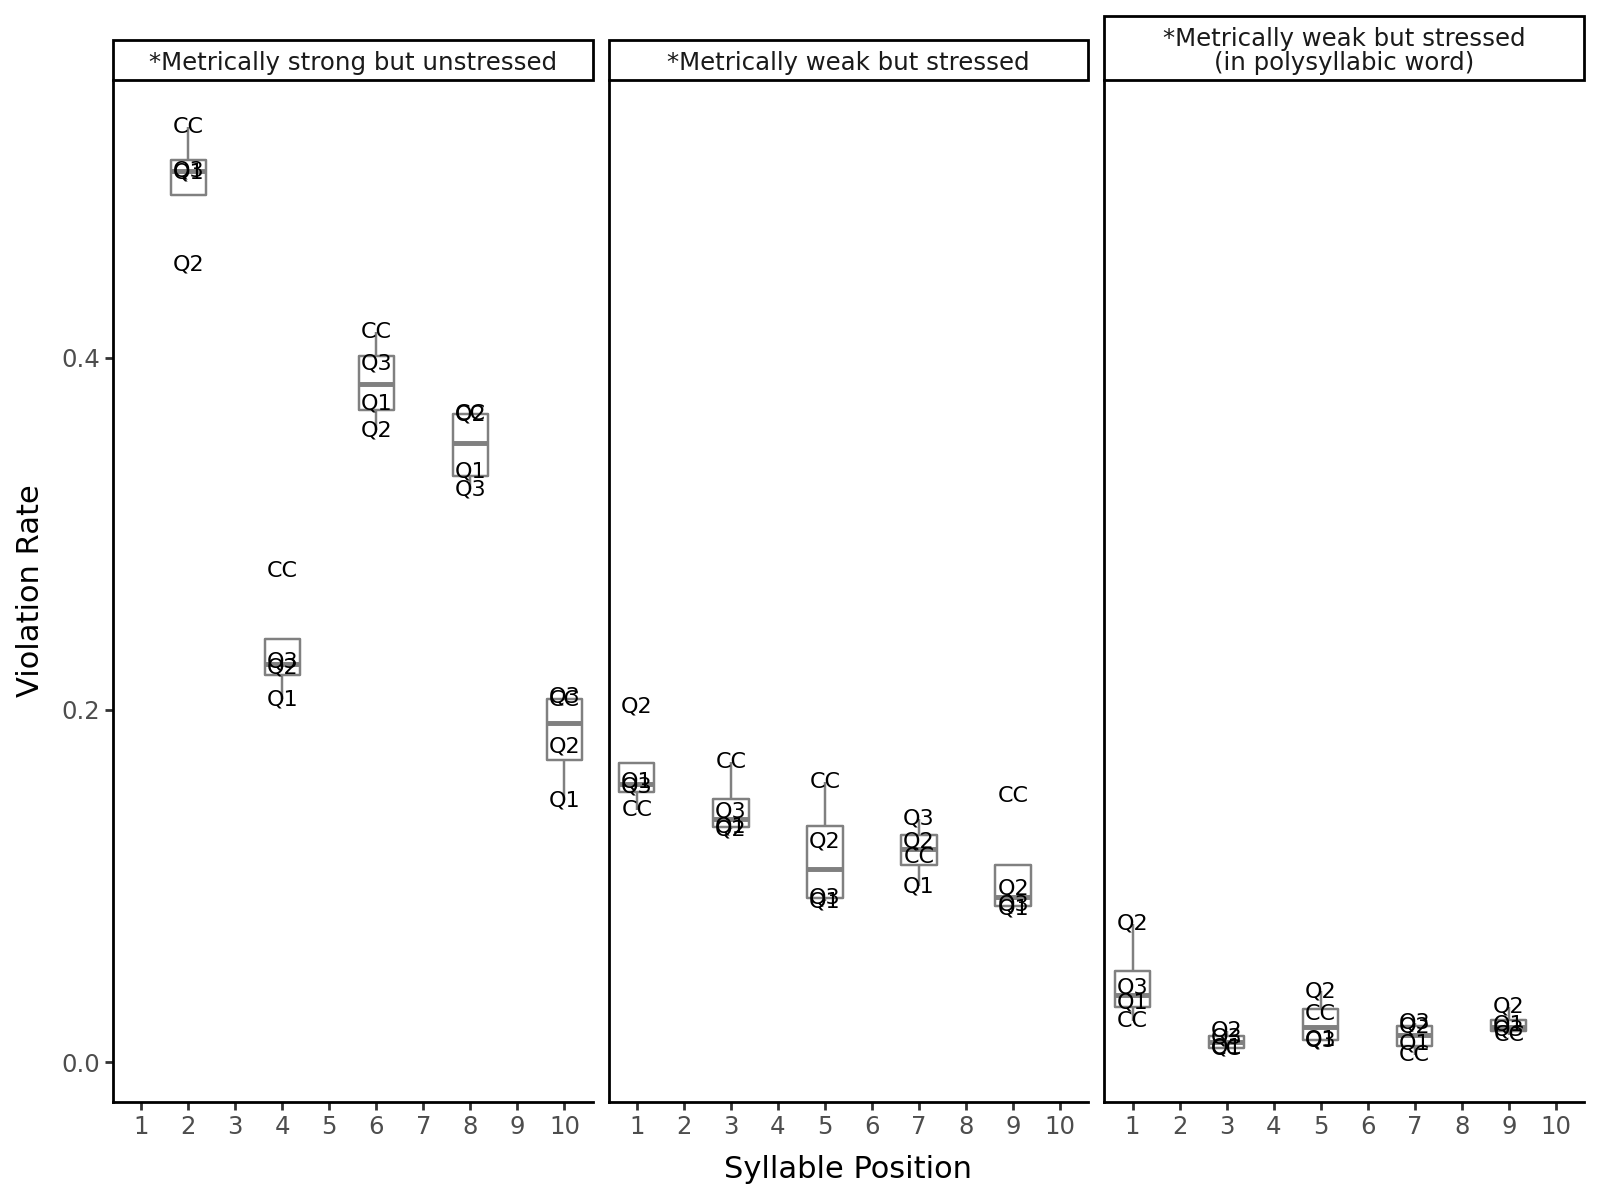

In [219]:
import plotnine as p9

figdf = parses_df.reset_index()

figdf = pd.concat(
    gdf.assign(meter_syll_num=gdf.sort_values(['meterpos_num', 'meterslot_num']).groupby(['meterpos_num','meterslot_num']).ngroup() + 1)
    for g,gdf in figdf.groupby(['stanza_num','line_num','parse_meter','parse_rank'])
)

def get_line_num_type(line_num):
    if line_num in [1,2,3,4]:
        return 'Q1'
    elif line_num in [5,6,7,8]:
        return 'Q2'
    elif line_num in [9,10,11,12]:
        return 'Q3'
    elif line_num in [13,14]:
        return 'CC'

figdf['line_num_type'] = figdf['line_num'].apply(get_line_num_type)

figdf = figdf.groupby(['meter_syll_num','line_num_type']).mean(numeric_only=True).reset_index()

# Get violation columns (those starting with *)
viol_cols = [col for col in figdf.columns if col.startswith('*')]

# Melt the DataFrame
figdf_melted = pd.melt(
    figdf,
    id_vars=['meter_syll_num','line_num_type'],
    value_vars=viol_cols,
    var_name='violation_type',
    value_name='violation_value'
)

# Clean up violation_type names by removing the *
figdf_melted['violation_type'] = figdf_melted['violation_type'].str.replace('*', '')

p9.options.figure_size = (8, 6)
figdf_melted['label'] = figdf_melted['violation_value'].apply(lambda x: f'{int(round(x*100))}%')

violnames = {
    's_unstress': '*Metrically strong but unstressed\n',
    'w_peak': '*Metrically weak but stressed\n(in polysyllabic word)',
    'w_stress': '*Metrically weak but stressed\n',
    'unres_across': '*Unresolved across',
    'unres_within': '*Unresolved within',
}

figdf_melted['violation_type'] = figdf_melted['violation_type'].apply(lambda x: violnames.get(x, x))
figdf_melted['meter_syll_num'] = pd.Categorical(figdf_melted['meter_syll_num'].astype(int))

import numpy as np
# Calculate mean and standard error for the line plot
line_data = (figdf_melted.query('violation_value > 0')
             .groupby(['meter_syll_num','violation_type'])
             .agg({
                 'violation_value': ['mean', 'std', 'count']
             })
             .reset_index())
line_data.columns = ['meter_syll_num', 'violation_type', 'mean', 'std', 'count']
line_data['se'] = line_data['std'] / np.sqrt(line_data['count'])
line_data['upper'] = line_data['mean'] + line_data['se']
line_data['lower'] = line_data['mean'] - line_data['se']

fig = (p9.ggplot(figdf_melted.query('violation_value > 0'), 
                 p9.aes(x='meter_syll_num', 
                        y='violation_value')) + 
       p9.geom_boxplot(outlier_shape='', color='gray') +
       p9.geom_line(data=figdf_melted.query('violation_value > 0').groupby(['meter_syll_num','violation_type']).mean(numeric_only=True).reset_index(), group='meter_syll_num', size=.25) +
    #    p9.geom_errorbar(p9.aes(y='mean', ymin='lower', ymax='upper'),
    #                     data=line_data,
    #                    width=0.2,color='gray') +
       p9.geom_text(p9.aes(label='line_num_type'),size=8) +
    #    p9.geom_point(p9.aes(shape='line_num_type'),size=2) +
       p9.theme_classic() +
       p9.facet_wrap('violation_type',nrow=1) +
       p9.labs(x='Syllable Position', 
               y='Violation Rate',
               fill='Violation Type'))
fig = fig + p9.theme(legend_position='bottom')

fig